In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [2]:
result = pd.read_csv("results.csv")
result

,pre,post,plen,threshold_0,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn
0,MBON32,AVLP178,2,True,False,False,False,False,False,0.000002
1,MBON32,AVLP178,3,True,True,False,False,False,False,0.000006
2,MBON32,AVLP178,4,True,True,False,False,False,False,0.000016
3,MBON32,AVLP178,5,True,True,True,False,False,False,0.000024
4,MBON32,CB2309,2,True,True,False,False,False,False,0.000074
...,...,...,...,...,...,...,...,...,...,...
44795,MLt3,AVLP339,5,True,True,True,False,False,False,0.000594
44796,MLt3,CB2694,2,True,True,False,False,False,False,0.000009
44797,MLt3,CB2694,3,True,True,False,False,False,False,0.000074
44798,MLt3,CB2694,4,True,True,True,False,False,False,0.000146


In [3]:
# make longer: all columns starting with 'threshold'
result = result.melt(id_vars=['plen', 'effconn','pre','post'], value_vars=[col for col in result.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
result['threshold'] = result['threshold'].str.replace('threshold_','')
result['path_length'] = result['plen'].astype(str)
result

,plen,effconn,pre,post,threshold,value,path_length
0,2,0.000002,MBON32,AVLP178,0,True,2
1,3,0.000006,MBON32,AVLP178,0,True,3
2,4,0.000016,MBON32,AVLP178,0,True,4
3,5,0.000024,MBON32,AVLP178,0,True,5
4,2,0.000074,MBON32,CB2309,0,True,2
...,...,...,...,...,...,...,...
268795,5,0.000594,MLt3,AVLP339,0.1,False,5
268796,2,0.000009,MLt3,CB2694,0.1,False,2
268797,3,0.000074,MLt3,CB2694,0.1,False,3
268798,4,0.000146,MLt3,CB2694,0.1,False,4


c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a

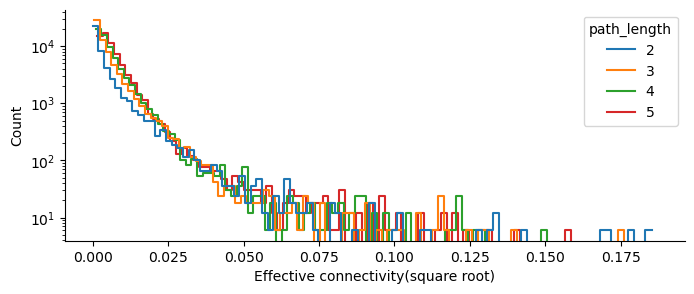

In [4]:
result["effconn_sqrt"] = np.sqrt(result["effconn"])

plt.figure(figsize=(8,3))
sns.histplot(
    data=result[result.effconn.notna()],
    x="effconn_sqrt",
    hue="path_length",
    bins=100,
    multiple="dodge",
    fill=False, 
    element="step",
)
plt.yscale("log")
plt.xlabel("Effective connectivity(square root)")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a

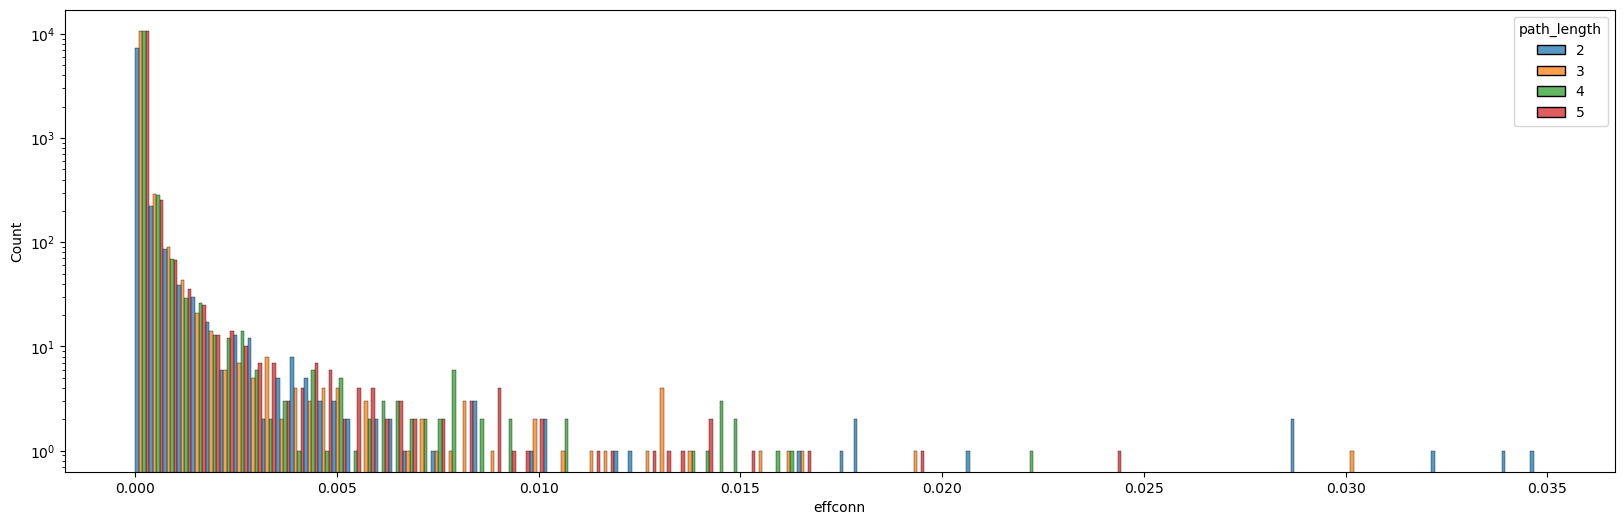

In [5]:
plt.figure(figsize=(20,6))
sns.histplot(data=result[result.effconn.notna()].drop_duplicates(['pre','post','path_length']), x="effconn", hue='path_length', bins = 100, 
multiple="dodge")
plt.yscale('log')


c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\44745\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a

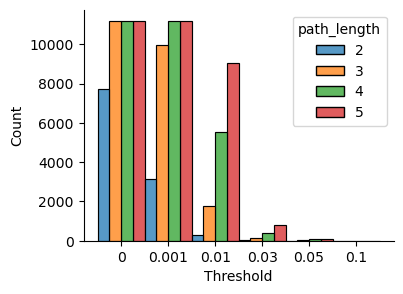

In [6]:
plt.figure(figsize=(4,3))
p = sns.histplot(
    result[result.value], x="threshold", hue="path_length", multiple="dodge"
)
# plt.yscale('log')
plt.xlabel("Threshold")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

In [7]:
result[result.value][["path_length", "threshold"]].value_counts()

path_length  threshold
4            0            11200
5            0.001        11200
             0            11200
4            0.001        11189
3            0            11177
             0.001         9952
5            0.01          9042
2            0             7735
4            0.01          5534
2            0.001         3164
3            0.01          1789
5            0.03           793
4            0.03           369
2            0.01           279
3            0.03           144
5            0.05           112
4            0.05            74
3            0.05            32
2            0.03            31
             0.05            11
5            0.1              5
4            0.1              4
3            0.1              3
2            0.1              1
Name: count, dtype: int64